# 

# Supplement: Scoping review results

In [ ]:
targets::tar_source('R')


qs2 0.1.5


Attaching package: 'janitor'

The following objects are masked from 'package:stats':

    chisq.test, fisher.test

Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.0; sf_use_s2() is TRUE

udunits database from /usr/share/udunits/udunits2.xml

## Results

PRISMA

-   3870 references imported for screening as 3870 studies
    -   128 duplicates identified manually
    -   799 duplicates identified by Covidence
-   2943 studies screened against title and abstract
    -   2527 studies excluded
-   416 studies assessed for full-text eligibility
    -   275 studies excluded
        -   184 Does not discuss dyadic measure
        -   86 Metric not applicable to spatiotemporal data
        -   2 Book chapter
        -   2 Full text not in English
        -   1 Thesis
    -   0 studies ongoing
    -   0 studies awaiting classification
-   141 studies included

In [ ]:
count_code_avail[, .N, analysis_code_availability][
  order(-N),
  .(
    `Code availability` = analysis_code_availability,
    N = paste_n_percent(N)
  )
] |>
  tt()


Code availability,N
No,114 (81%)
Yes,26 (19%)


In [ ]:
list_prog <- count_prog_lang[,
  uniqueN(covidence_number),
  .(prog = !is.na(programming_language))
]
unique_prog_lang <- count_prog_lang[,
  uniqueN(programming_language),
  covidence_number
]


Out of 141 articles, 52 did not list a programming language or GUI program. Of the 89 that did, 21 articles listed more than one programming language or GUI program, therefore the total count below will be greater than the number of articles.

In [ ]:
count_prog_lang[, .N, programming_language][
  order(-N),
  .(
    `Programming language` = programming_language,
    N = paste_n_percent(N)
  )
] |>
  tt()


Programming language,N
R,62 (36.26%)
NA,52 (30.41%)
MATLAB,15 (8.77%)
Python,6 (3.51%)
CUDA,4 (2.34%)
Ucinet,3 (1.75%)
Perl,3 (1.75%)
C++,3 (1.75%)
NetLogo,2 (1.17%)
SPSS,2 (1.17%)


Out of 140 articles, 112 did not list a software package. Of the 28 that did, 14 articles listed more than one software package , therefore the total count below will be greater than the number of articles.

In [ ]:
count_software[, .N, software_package_s_used][
  order(-N),
  .(
    `Software package used` = software_package_s_used,
    N = paste_n_percent(N)
  )
] |>
  tt()


Software package used,N
NA,112 (66.67%)
wildlifeDI,9 (5.36%)
geosphere,3 (1.79%)
adehabitat,2 (1.19%)
moveVis,2 (1.19%)
ctmm,2 (1.19%)
CircStats,2 (1.19%)
corrMove,2 (1.19%)
adehabitatHR,2 (1.19%)
numpy,2 (1.19%)


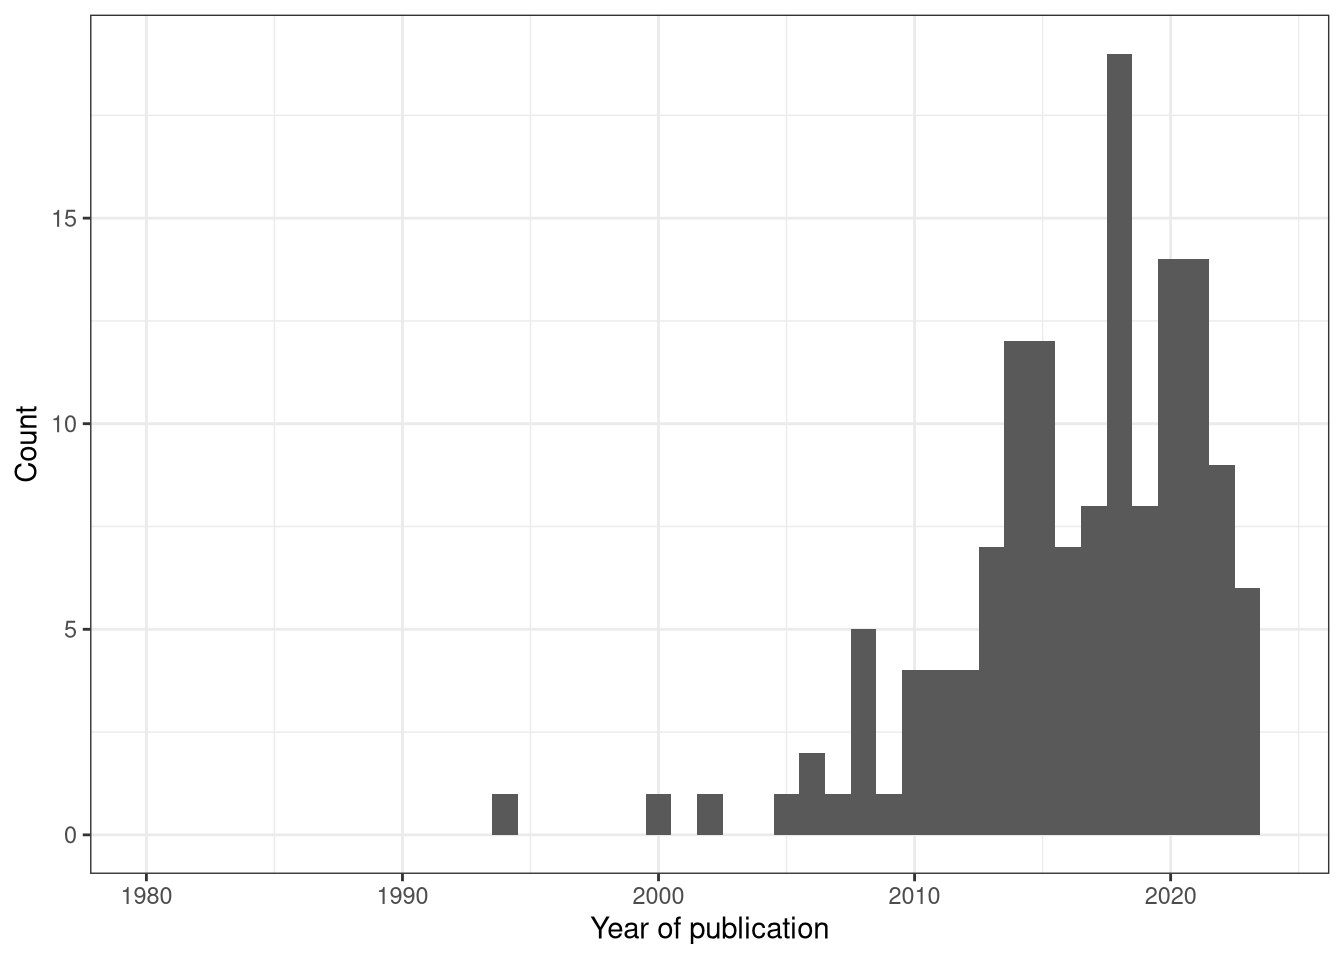

In [ ]:
ggplot(review) +
  geom_histogram(aes(yr), binwidth = 1) +
  labs(x = 'Year of publication', y = 'Count') +
  coord_cartesian(xlim = c(1980, 2024)) +
  theme_bw()


Warning in CPL_crs_from_input(x): GDAL Message 1: EPSG:54030 is not a valid CRS
code, but ESRI:54030 is. Assuming ESRI:54030 was meant

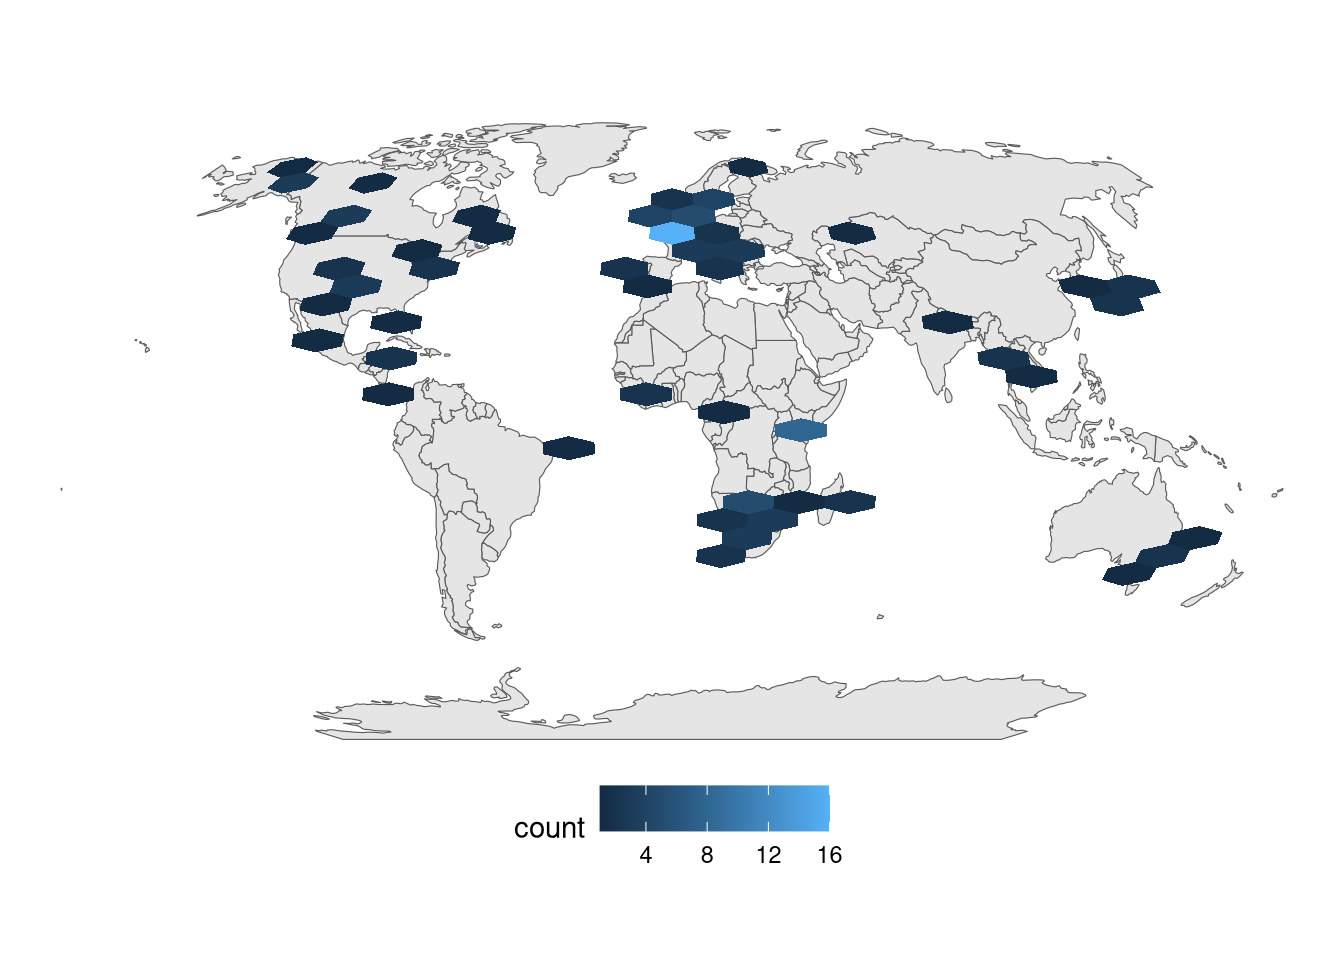

In [ ]:
countries <- ne_countries()

ggplot() +
  geom_sf(data = countries) +
  geom_hex(
    aes(long, lat),
    alpha = 1,
    bins = 20,
    data = geocoded[!is.na(long)]
  ) +
  coord_sf(crs = 54030, default_crs = 4326) +
  theme_void() +
  theme(legend.position = 'bottom')


In [ ]:
taxized[, .N, parsed_species][
  order(-N),
  .(
    Species = parsed_species,
    N = paste_n_percent(N)
  )
] |>
  tt() |>
  style_tt(j = "Species", italic = TRUE)


Species,N
Columba livia,9 (7.09%)
Danio rerio,6 (4.72%)
Rangifer tarandus,6 (4.72%)
Gasterosteus aculeatus,5 (3.94%)
Papio anubis,5 (3.94%)
Poecilia reticulata,5 (3.94%)
Macaca fuscata,4 (3.15%)
Ovis aries,4 (3.15%)
Bos taurus,3 (2.36%)
Ateles geoffroy,3 (2.36%)


In [ ]:
count_metric[, .N, metric_agg][
  order(-N),
  .(
    `Metric` = metric_agg,
    N = paste_n_percent(N)
  )
] |>
  tt()


Metric,N
interindividual distance,61 (14.73%)
nearest neighbour distance,19 (4.59%)
directional correlation delay,18 (4.35%)
speed,17 (4.11%)
position within group,16 (3.86%)
direction,15 (3.62%)
zones,15 (3.62%)
distance to group centroid,14 (3.38%)
fission fusion,13 (3.14%)
directional alignment,9 (2.17%)


In [ ]:
count_dom_metric[, .N, dominance_metric_agg][
  order(-N),
  .(
    `Dominance metric` = dominance_metric_agg,
    N = paste_n_percent(N)
  )
] |>
  tt()


Dominance metric,N
NA,112 (77.24%)
focal observations,14 (9.66%)
direction correlation delay,5 (3.45%)
fleeing events,2 (1.38%)
survey,2 (1.38%)
approach-avoidance events,2 (1.38%)
egalitarian leadership index,1 (0.69%)
movement initiations,1 (0.69%)
proportion of paired flights led,1 (0.69%)
spatially constrained trend-setter,1 (0.69%)


In [ ]:
review[definition_category == 'group', .(study_id, definition)] |>
  tt()


study_id,definition
Quaglietta 2014,interaction if within 100 m and 1 hour
Mielke 2020,group defined as all individuals within visual contact of focal individual
Leighty 2008,proximity defined as 8 m; approach/avoidance after event defined as changes in interindividual distance after an event
Hansen 2015,fish considered isolated if not within three body lengths of any other fish; group defined by within three body lengths
Bista 2022,"temporal threshold 2 hour, distance threshold 100 m"
Pinacho-Guendulain 2017,group using 30 m chain rule
Lemasson 2014,group when within 5 body lengths
Inoue 2019,proximity defined as two body lengths away


In [ ]:
review[definition_category == 'leadership', .(study_id, definition)] |>
  tt()


study_id,definition
Rahman 2020,leadership as tendency to be at the front of the group
Quera 2023,"following Krause et al. (2000) and Collignon et al. (2019), the authors define a motion leader as an individual who initiates movement towards a certain direction and is followed by other group members"
Andrienko 2013,leader is an object that moves in front of others; trend setter is an object whose movements are copied by others
Amornbunchornvej 2018,following relation is where two individuals perform the same sequence of actions with some fixed delay; initiator is individual who first performs a sequence of actions and all other individuals follow
Kano 2021,leader from directional correlation delay
Pettit 2013,leadership based on directional correlation delay; leadership also based on tendency to use route taken on solo flight
Pérez-Barbería 2018,leadership is ranked position along front-back axis
Laube 2005,leadership extends flock with constance over previous time steps
Milner 2021,leader is animal that is dominant to at least one and subordinate to none
Strandburg-Peshkin 2018,an individual leads if it has repeated influence either directly or hierarchically on the behaviour of others


In [ ]:
review[definition_category == 'fission fusion', .(study_id, definition)] |>
  tt()


study_id,definition
Baden 2016,NA
Aguilar-Melo 2018,fission when gte 1 were not observed with a group for 2 consecutive scans; fusion when gte 1 who were previously not observed with group are observed with group for 2 consecutive scans
Barocas 2016,fission and fusion defined as joining and leaving group in subsequent observations
Haydon 2008,fusion where solitary to grouped and fission where grouped to solitary
Fortin 2009,group/fusion when within 100 m; fission when two or more consecutive locations separated by > 100 m
Body 2015,fusion gte 2 groups merging into one; fission one group splitting into gte 2
DellaLibera 2023,"define a fission and fusion event if one or more individuals left or joined the group, respectively. in the rare cases of missing data, missing individuals are not considered as having changed group membership, and individual ‘disappearances’ and ‘reappearances’ in the dataset are not considered as fission–fusion events"
Wielgus 2020,group where simultaneously within 1 km or >= 1 km for <= 2 hr; fusion where together then different by one time step; fission reverse
Nishikawa 2014,converged when IID less than 20 m; separated when IID greater than 20 m; converged and separated synonymous with fission fusion
Krueger 2014,NA
